# Машинное обучение, ФКН ВШЭ
## Практическое задание 3.

Задание состоит из трех независимых разделов, посвященных bias-variance decomposition, решающим деревьям и композициям алгоритмов. Эти разделы можно выполнять в любом порядке. В каждом разделе вам предложена одна или две задачи, которые, в свою очередь, делятся на пункты. Баллы даются за выполнение пунктов, причем в рамках одной задачи пункты, как правило, зависимы (нельзя решить следующий, не решив предыдущего). Пункты могут быть двух видов: написать скрипт или ответить на вопросы. Задачи в рамках одного раздела рекомендуется решать в том порядке, в котором они даны в задании. В разных задачах используются разные наборы данных, все наборы взяты из репозитория UCI. 

Задание направлено на более глубокое ознакомление с тем, как работают решающие деревья, случайные леса и как устроено разложение на смещение и разброс. Кроме того, задание предполагает проведение экспериментов и анализ их результатов (мини-исследования). 

### Формат сдачи
Для сдачи задания переименуйте получившийся файл \*.ipynb в соответствии со следующим форматом: *HW1_Username.ipynb*, где *Username* — Ваша фамилия и инициалы на латинице (например, *HW1_IvanovII.ipynb*). Далее отправьте этот файл на Smorodinov-1990@mail.ru.

### I. Разложение ошибки на смещение и разброс
#### Теоретическое вступление
На занятиях мы разбирали примеры аналитического вычисления смещения и разброса нескольких алгоритмов обучения. Для большинства моделей данных и алгоритмов обучения аналитически рассчитать математические ожидания в формулах не удастся. Однако мат. ожидания можно оценивать приближенно. Чтобы оценить математическое ожидание $\mathbb{E}_{\bar x} f(\bar x)$ функции от многомерной случайной величины $\bar x = (x_1, \dots, x_d)$, $\bar x \sim p(\bar x)$, можно сгенерировать выборку из распределения $p(\bar x)$ и усреднить значение функции на элементах этой выборки:
$$\mathbb{E}_{\bar x} f(x) = \int f(\bar x) p(\bar x) d \bar x \approx \frac 1 m \sum_{i=1}^m f(\bar x_i), \, \bar x_i \sim p(\bar x), i = 1, \dots, m.$$

Для оценки многомерных интегралов ($d > 1$) объекты лучше генерировать, следуя специальным схемам, чтобы адекватно оценивать значение интеграла в областях высокой плотности. Мы не будем так усложнять задачу, а просто будем генерировать $\bar x_i$ независимо.

In [1]:
import numpy as np

Например, оценим $\mathbb{E}_x x^2,$ $x \sim \mathcal{N}(\mu=5, \sigma=3)$ (из теории вероятностей мы знаем, что
$\mathbb{E}_x x^2 = \sigma^2 + \mu^2 = 34$):

In [2]:
x = np.random.normal(loc=5, scale=3, size=1000)
(x**2).mean()

np.float64(34.161078811702325)

Или посчитаем многомерный интеграл $\mathbb{E}_{\bar x} \bar x^T \bar x = \mathbb{E}_{\bar x} \sum_{i=1}^d x_i^2$, $\bar x \sim \mathcal{N}(\bar \mu=(1, \dots, 1), \Sigma=I)$ при $d = 10$ (аналитический ответ 20):

In [3]:
d = 10
X = np.random.multivariate_normal(np.ones(10), np.eye(10), size=1000)
(X**2).sum(axis=1).mean()

np.float64(19.735900663312183)

Чтобы оценить интеграл по выборке, можно сгенерировать несколько выборок, вычислить на них значение функции и усреднить. Например, для интеграла $\mathbb{E}_X [\mu(X)(x)]$ генерируются выборки $X_1, \dots, X_m$, на каждой из них обучается алгоритм $\mu$ и делается предсказание для объекта $x$.

#### Практическая часть
##### Задача 1. Построение "среднего" алгоритма $\mathbb{E}_X [\mu(X)]$
В этом задании вам нужно построить графики, демонстрирующие, как алгоритм $\mathbb{E}_X [\mu(X)]$ аппроксимирует истинную зависимость в данных и как он меняется в зависимости от гиперпараметров метода обучения.

In [4]:
from matplotlib import pyplot as plt
%matplotlib inline

In [5]:
def f(x):
    return np.sin(x)   # истинная зависимость в данных
sample_size = 100      # длина выборки
samples_num = 20       # количество выборок
linspace = np.linspace(0, 7, 1000)  # точки для построения графиков

__1 (0.3 балла)__
1. Сгенерируйте выборку x из одномерного экспоненциального распределения (np.random.exponential) длины sample_size.
1. Создайте вектор целевых переменных y как сумму f(x) и случайного шума, сгенерированного из равномерного распределения на отрезке [-1, 1] (np.random.uniform).
1. Обучите DecisionTreeRegressor с параметрами по умолчанию на полученной выборке и сделайте предсказания для объектов из linspace.
1. Постройте два графика на одном рисунке: f(x) и зависимость, восстановленную решающим деревом.

    Рекомендация: не забудьте, что все методы обучения в sklearn требуют на вход двумерную матрицу объекты-признаки. Сделать такую из одномерного вектора можно добавлением мнимых осей (np.newaxis).

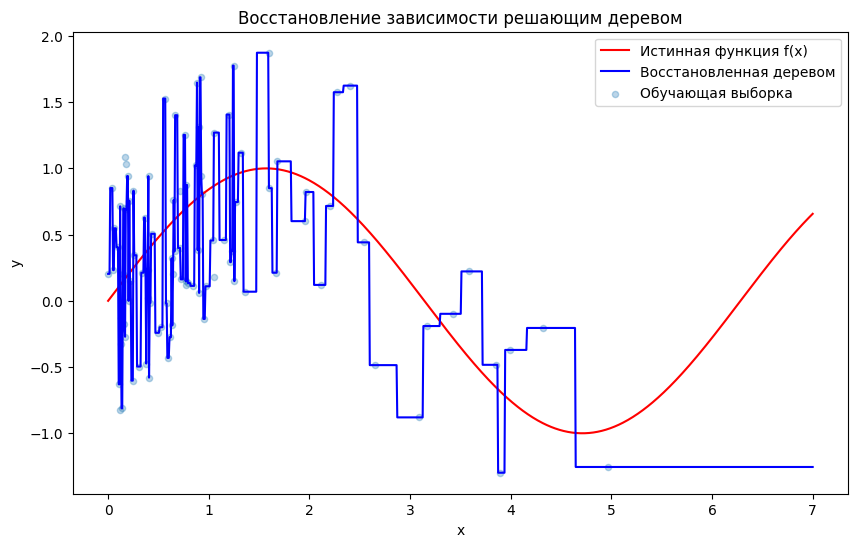

In [6]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np

x = np.random.exponential(scale=1.0, size=sample_size)
noise = np.random.uniform(-1, 1, size=sample_size)
y = f(x) + noise

tree = DecisionTreeRegressor()
tree.fit(x[:, np.newaxis], y)
y_pred = tree.predict(linspace[:, np.newaxis])

plt.figure(figsize=(10, 6))
plt.plot(linspace, f(linspace), label='Истинная функция f(x)', color='red')
plt.plot(linspace, y_pred, label='Восстановленная деревом', color='blue')
plt.scatter(x, y, s=20, alpha=0.3, label='Обучающая выборка')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Восстановление зависимости решающим деревом')
plt.show()

__2 (0.3 балла):__

Повторите первые 3 шага, описанные выше, samples_num раз. На одном графике для каждого обученного решающего дерева визуализируйте восстановленную им зависимость (рекомендуется все такие линии рисовать полупрозрачными и серым цветом: plt.plot(...... color="gray", alpha=0.5)).  На этом же графике изобразите истинную зависимость f(x) (красным цветом: color="red") и усредненную по всем деревьям восстановленную зависимость (черным цветом: color="black").    

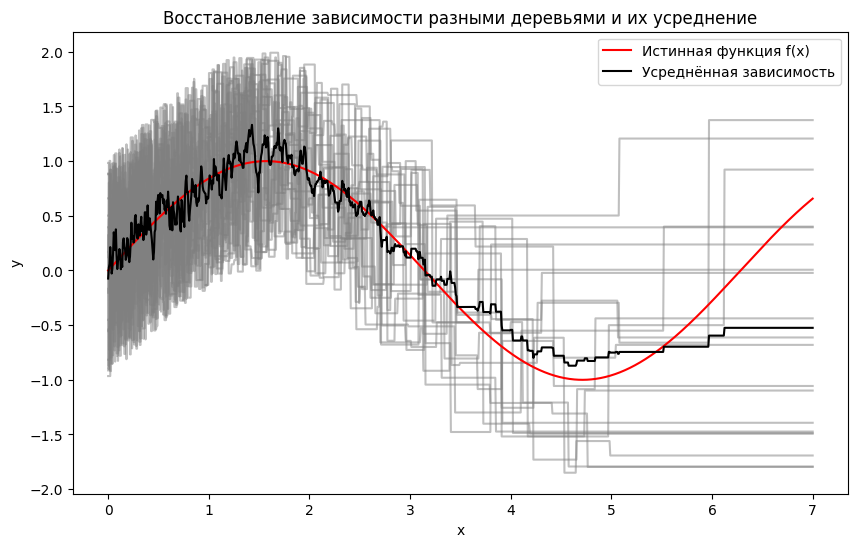

In [7]:
all_preds = []

plt.figure(figsize=(10, 6))

for _ in range(samples_num):
    x = np.random.exponential(scale=1.0, size=sample_size)
    noise = np.random.uniform(-1, 1, size=sample_size)
    y = f(x) + noise
    tree = DecisionTreeRegressor()
    tree.fit(x[:, np.newaxis], y)
    y_pred = tree.predict(linspace[:, np.newaxis])
    all_preds.append(y_pred)
    plt.plot(linspace, y_pred, color="gray", alpha=0.5)

plt.plot(linspace, f(linspace), color="red", label="Истинная функция f(x)")

mean_pred = np.mean(all_preds, axis=0)
plt.plot(linspace, mean_pred, color="black", label="Усреднённая зависимость")

plt.xlabel('x')
plt.ylabel('y')
plt.title('Восстановление зависимости разными деревьями и их усреднение')
plt.legend()
plt.show()


__3 (0.1 балла):__
Повторите предыдущий пункт, установив максимальную глубину решающего дерева равной 2, а затем равной 4. Таким образом, у вас получится еще два графика.

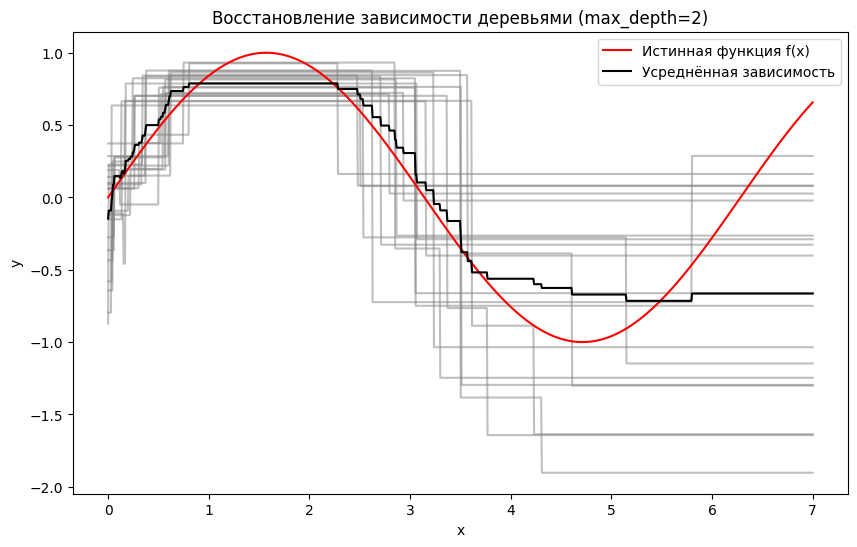

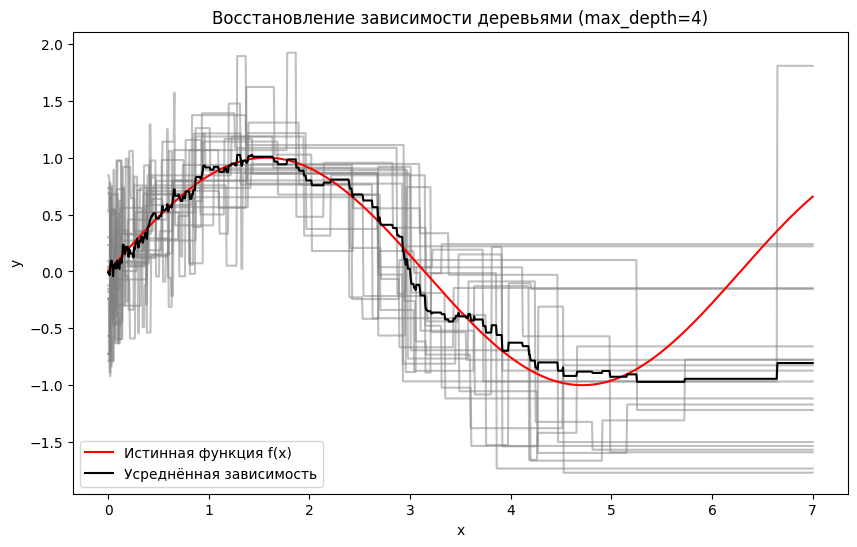

In [8]:
for max_depth in [2, 4]:
    all_preds = []
    plt.figure(figsize=(10, 6))
    for _ in range(samples_num):
        x = np.random.exponential(scale=1.0, size=sample_size)
        noise = np.random.uniform(-1, 1, size=sample_size)
        y = f(x) + noise
        tree = DecisionTreeRegressor(max_depth=max_depth)
        tree.fit(x[:, np.newaxis], y)
        y_pred = tree.predict(linspace[:, np.newaxis])
        all_preds.append(y_pred)
        plt.plot(linspace, y_pred, color="gray", alpha=0.5)
    plt.plot(linspace, f(linspace), color="red", label="Истинная функция f(x)")
    mean_pred = np.mean(all_preds, axis=0)
    plt.plot(linspace, mean_pred, color="black", label="Усреднённая зависимость")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Восстановление зависимости деревьями (max_depth={max_depth})')
    plt.legend()
    plt.show()


__4 (0.3 балла)__ Что можно сказать о смещении решающих деревьев, исходя из проведенного эксперимента? В каких из трех рассмотренных случаев (без ограничения на глубину дерева и с ограничением 2 и 4) можно утверждать, что смещение решающего дерева близко к нулю?

Самые лучшие это без ограничения и с глубиной 4




#### Задача 2. Приближенное оценивание смещения и разброса
Реализуем стохастическую процедуру оценивания смещения и разброса алгоритма.

Будем считать, что каждый объект представлен одним признаком, сгенерированным из некоторого распределения, а значение целевой переменной на этом объекте - это сумма значения истинной функции на объекте плюс шумовая компонента, также сгенерированная из некоторого распределения.

__4 (1 балл) __Реализуйте функцию:

In [9]:
def compute_bias_variance(regressor, dependence_fun, x_generator=np.random.uniform, noise_generator=np.random.uniform,
                          sample_size=100, samples_num=100, objects_num=50):
    x_objects = x_generator(size=objects_num)
    x_objects = x_objects.reshape(-1, 1)
    y_true = dependence_fun(x_objects.ravel())

    noise_mean = noise_generator(size=objects_num).mean()
    y_expected = y_true + noise_mean

    all_preds = []
    for _ in range(samples_num):
        x_train = x_generator(size=sample_size).reshape(-1, 1)
        y_train = dependence_fun(x_train.ravel()) + noise_generator(size=sample_size)
        reg = regressor.__class__(**regressor.get_params())
        reg.fit(x_train, y_train)
        y_pred = reg.predict(x_objects)
        all_preds.append(y_pred)
    all_preds = np.array(all_preds)
    y_pred_mean = all_preds.mean(axis=0)
    bias = np.mean((y_expected - y_pred_mean) ** 2)
    variance = np.mean(np.var(all_preds, axis=0))
    
    return bias, variance

bias, variance = compute_bias_variance(
    DecisionTreeRegressor(),
    np.sin,
    x_generator=np.random.uniform,
    noise_generator=lambda size: np.random.normal(0, 0.1, size=size)
)

print("Bias:", bias)
print("Variance:", variance)

Bias: 0.0003316484882096678
Variance: 0.00993290739983513


Параметры:
* regressor: объект sklearn-класса, реализующего регрессионный алгоритм (например, DecisionTreeRegressor, LinearRegression, Lasso, RandomForestRegressor ...)
* dependence_fun: функция, задающая истинную зависимость в данных. Принимает на вход вектор и возвращает вектор такой же длины. Примеры: np.sin, lambda x: x\*\*2.
* x_generator: функция, генерирующая одномерную выборку объектов и имеющая параметр size (число объектов в выборке). По умолчанию np.random.uniform.
* noise_generator: функция, генерирующая одномерную выборку шумовых компонент (по одной на каждый объект) и имеющая параметр size (число объектов в выборке). По умолчанию np.random.uniform.
* sample_size: число объектов в выборке.
* samples_num: число выборок, которые нужно сгенерировать, чтобы оценить интеграл по X
* objects_num: число объектов, которые нужно сгенерировать, чтобы оценить интеграл по x.

Вовращаемые значения:
* Смещение алгоритма regressor (число)
* Разброс алгоритма regressor (число)

_Рекомендации:_ 
* Создайте вектор объектов для оценивания интеграла по $x$, затем вектор правильных ответов на нем и вектор зашумленных правильных ответов. $\mathbb{E}[y|x]$ оценивается как сумма правильного ответа на объекте и мат. ожидания шума (который оценивается генерацией отдельной шумовой выборки длины objects_num и усреднением значений в ней). $\mathbb{E}_X [\mu(X)]$ оценивается как в предыдущей задаче: нужно обучить regressor на samples_num выборках длины sample_size и усреднить предсказания на сгенерированных ранее объектах. Смещение - это среднее квадрата разности вектора зашумленных ответов и вектора предсказаний. Для оценки разброса нужно еще раз сгенерировать samples_num выборок.
* Проверить правильность реализации можно на примерах, которые разбирались на семинаре и в домашней работе.

__5 (0.4 балла) Заполните таблицу.__ 

Пусть истинная зависимость данных задается функцией $5\sin (10 x)$, а значения признаков и шум генерируются из одного и того же распределения. Будем пробовать 4 разных распределения и сравнивать 4 регрессионных алгоритма (см. таблицы ниже). Необходимо в каждую ячейку датафреймов bias и variance записать записать соответственно смещение и разброс, рассчитанные для алгоритма, задаваемого строкой таблицы, и генератора случайных чисел, задаваемого столбцом. Остальные параметры функции compute_bias_variance оставьте по умолчанию.

In [10]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [14]:
regressors = [LinearRegression(), 
              DecisionTreeRegressor(), 
              RandomForestRegressor(),
              GradientBoostingRegressor()]
regressor_names = ["LinearRegression", "DecisionTree", "RandomForest", "GradientBoosting"]
generators = [lambda size: np.random.normal(0, 0.3, size=size), 
              lambda size: np.random.exponential(0.3, size=size), 
              lambda size: np.random.uniform(-1, 1, size=size),
              np.random.uniform]
generator_names = ["normal(0, 0.3)", "exponential(0.3)", "uniform(-1, 1)", "uniform(0, 1)"]


In [12]:
bias = pd.DataFrame(columns=["normal(0, 0.3)", "exponential(0.3)", "uniform(-1, 1)", "uniform(0, 1)"],
                      index=["LinearRegression", "DecisionTree", "RandomForest", "GradientBoosting"])
variance = pd.DataFrame(columns=bias.columns, index=bias.index)

In [13]:
bias

,"normal(0, 0.3)",exponential(0.3),"uniform(-1, 1)","uniform(0, 1)"
LinearRegression,NaN,NaN,NaN,NaN
DecisionTree,NaN,NaN,NaN,NaN
RandomForest,NaN,NaN,NaN,NaN
GradientBoosting,NaN,NaN,NaN,NaN


In [16]:
def true_fun(x):
    return 5 * np.sin(10 * x)

for i, reg in enumerate(regressors):
    for j, gen in enumerate(generators):
        b, v = compute_bias_variance(
            reg,
            true_fun,
            x_generator=gen,
            noise_generator=gen
        )
        bias.iloc[i, j] = b
        variance.iloc[i, j] = v
        print(f"{regressor_names[i]} + {generator_names[j]}: bias={b:.4f}, variance={v:.4f}")

# Выводим таблицы
print("Bias:")
display(bias)
print("Variance:")
display(variance)


LinearRegression + normal(0, 0.3): bias=14.8503, variance=0.2643
LinearRegression + exponential(0.3): bias=5.9711, variance=0.1495
LinearRegression + uniform(-1, 1): bias=11.4840, variance=0.2167
LinearRegression + uniform(0, 1): bias=12.1410, variance=0.2143
DecisionTree + normal(0, 0.3): bias=0.0081, variance=0.2257
DecisionTree + exponential(0.3): bias=0.0466, variance=0.3640
DecisionTree + uniform(-1, 1): bias=0.0228, variance=0.6092
DecisionTree + uniform(0, 1): bias=0.0024, variance=0.1577
RandomForest + normal(0, 0.3): bias=0.1158, variance=0.1988
RandomForest + exponential(0.3): bias=0.0343, variance=0.1181
RandomForest + uniform(-1, 1): bias=0.0248, variance=0.3180
RandomForest + uniform(0, 1): bias=0.0081, variance=0.0876
GradientBoosting + normal(0, 0.3): bias=0.0193, variance=0.2406
GradientBoosting + exponential(0.3): bias=0.0301, variance=0.3997
GradientBoosting + uniform(-1, 1): bias=0.0332, variance=0.4876
GradientBoosting + uniform(0, 1): bias=0.0096, variance=0.1240
B

,"normal(0, 0.3)",exponential(0.3),"uniform(-1, 1)","uniform(0, 1)"
LinearRegression,14.850302,5.971106,11.484034,12.14102
DecisionTree,0.008057,0.046571,0.022838,0.002399
RandomForest,0.11576,0.034254,0.024837,0.008057
GradientBoosting,0.019251,0.030147,0.033155,0.009631


Variance:


,"normal(0, 0.3)",exponential(0.3),"uniform(-1, 1)","uniform(0, 1)"
LinearRegression,0.264272,0.149456,0.216726,0.214265
DecisionTree,0.225735,0.364009,0.609237,0.157672
RandomForest,0.198809,0.118069,0.318012,0.087624
GradientBoosting,0.240615,0.399674,0.487555,0.124046


__6 (0.6 балла) Проанализируйте полученные таблицы. Ответьте на вопросы:__
* Отранжируйте алгоритмы в порядке увеличения разброса (если какие-то алгоримты в разных случаях ранжируются по-разному, поставьте их на одну ступень). Согласуется ли полученный результат с теоретическими рассуждениями из лекций (поясните, почему да или нет)?
* Можно ли сказать, что смещение и разброс алгоритма определяются только самим алгоритмом и не зависят от вероятностной модели данных, к которым этот алгоритм применяется (поясните, почему да или нет)? 
* Для каких распределений смещение решающих деревьев велико (по сравнению с другими распределениями)? Как вы думаете, почему так происходит (какие особенности этих распределений приводят к большому смещению)?

(・・ ) ?



__6* (0.5 доп. балла)__

Постройте графики зависимости смещения и разброса от sample_size, samples_num и objects_num (при варьировании одного параметра остальные два остаются по умолчанию) для четырех рассмотренных регрессионных алгоритмов. Сделайте выводы о том, как эти параметры влияют на дисперсию оценок.

### II. Решающие деревья своими руками
#### Задача 3.
В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__7 (0.5 балла)__

Реализуйте следующую функцию:

In [17]:
def find_best_split(feature_vector, target_vector):
    order = np.argsort(feature_vector)
    x_sorted = feature_vector[order]
    y_sorted = target_vector[order]
    n = len(x_sorted)

    mask = y_sorted[:-1] != y_sorted[1:]
    possible_thresholds = (x_sorted[:-1] + x_sorted[1:]) / 2
    thresholds = possible_thresholds[mask]
    if len(thresholds) == 0:
        return np.array([]), np.array([]), None, None

    left_mask = x_sorted[np.newaxis, :] <= thresholds[:, np.newaxis]
    right_mask = ~left_mask

    n_left = left_mask.sum(axis=1)
    n_right = right_mask.sum(axis=1)
    p1_left = (y_sorted * left_mask).sum(axis=1) / np.maximum(n_left, 1)
    p0_left = 1 - p1_left
    p1_right = (y_sorted * right_mask).sum(axis=1) / np.maximum(n_right, 1)
    p0_right = 1 - p1_right

    H_left = 1 - p1_left**2 - p0_left**2
    H_right = 1 - p1_right**2 - p0_right**2

    Q = -n_left / n * H_left - n_right / n * H_right

    valid = (n_left > 0) & (n_right > 0)
    thresholds = thresholds[valid]
    Q = Q[valid]

    if len(Q) == 0:
        return np.array([]), np.array([]), None, None

    best_idx = np.argmax(Q)
    best_threshold = thresholds[best_idx]
    best_gini = Q[best_idx]

    return thresholds, Q, best_threshold, best_gini
    
x = np.array([1, 2, 3, 4, 5])
y = np.array([0, 0, 1, 1, 1])
thresholds, ginis, best_threshold, best_gini = find_best_split(x, y)
print("Thresholds:", thresholds)
print("Ginis:", ginis)
print("Best threshold:", best_threshold)
print("Best gini:", best_gini)

Thresholds: [2.5]
Ginis: [-0.]
Best threshold: 2.5
Best gini: -0.0


Параметры:
* feature_vector: вещественнозначный вектор значений признака (np.array)
* target_vector: вектор классов объектов (np.array). len(feature_vector)==len(target_vector).

Возвращаемые значения:
* thresholds: отсортированный по возрастанию вектор со всеми возможными порогами, по которым объекты можно разделить на две различные подвыборки, или поддерева (np.array)
* ginis: вектор со значениями критерия Джини для каждого из порогов в thresholds. (np.array, len(ginis)==len(thresholds))
* оптимальный порог (число)
* оптимальное значение критерия Джини (число)

Под критерием Джини здесь подразумевается следующая функция:
$$Q(R) = -\frac {|R_l|}{|R|}H(R_l) -\frac {|R_r|}{|R|}H(R_r),$$
$R$ - множество объектов, $R_l$ и $R_r$ - объекты, попавшие в левое и правое поддерево, $H(R) = 1-p_1^2-p_0^2$, $p_1$, $p_0$ - доля объектов класса 1 и 0 соответственно.

Указания:
* Пороги, приводящие к попаданию в одно из поддеревьев пустого множества объектов, не рассматриваются.
* Поведение функции в случае константного признака может быть любым
* За наличие в функции циклов балл будет снижен. Векторизуйте! :)

__8 (0.5 балла)__
Загрузите датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling). Признаки объекта записаны в первых пяти столбцах, а в последнем преобразуйте целевую переменную в бинарную (класс: 0 [very_low, Low] или 1 [Middle, High]). Постройте на одном изображении пять кривых "порог - значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака - класс" для всех пяти признаков.

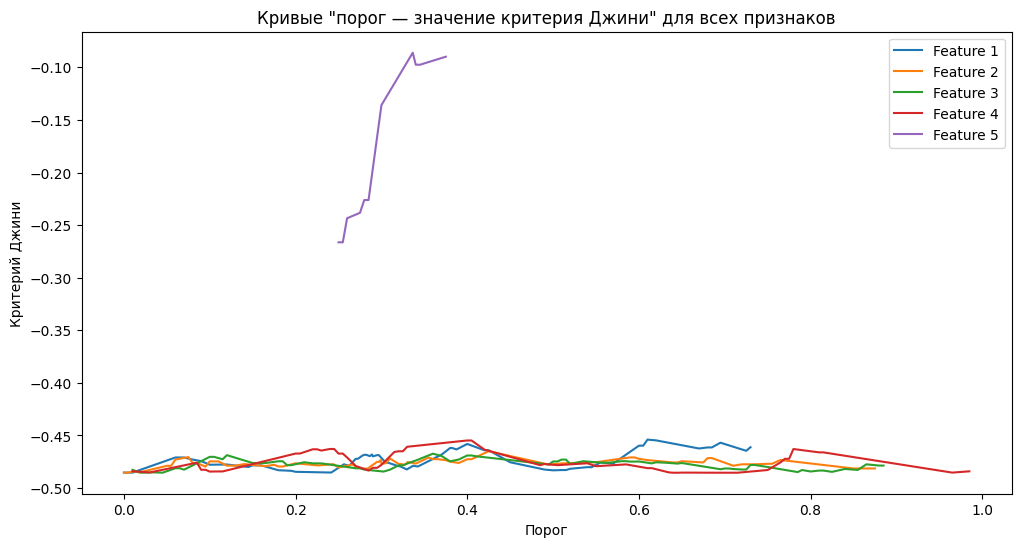

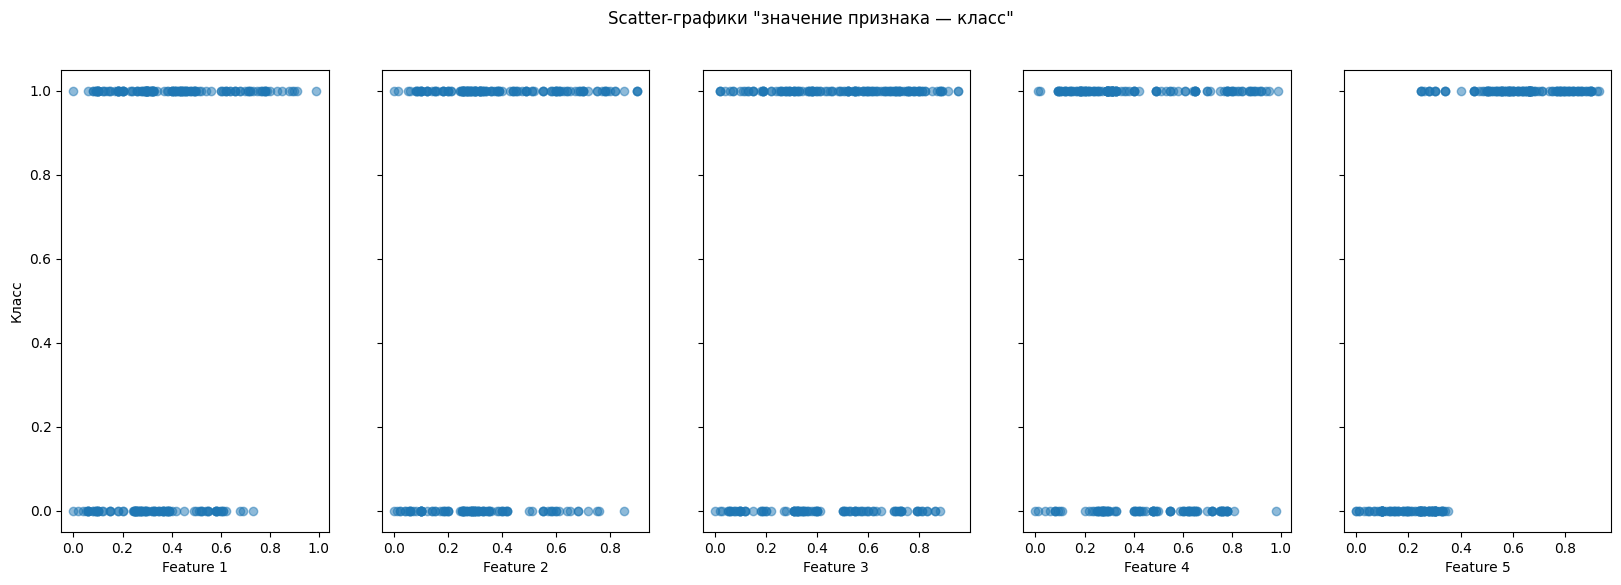

In [46]:
from sklearn.preprocessing import LabelEncoder
df = pd.read_excel('Data_user.xls')

X = df.iloc[:, :5].apply(pd.to_numeric, errors='coerce').values
y_raw = df.iloc[:, -1].values

y = np.array([0 if val in ['very_low', 'Low'] else 1 for val in y_raw])

plt.figure(figsize=(12, 6))
for i in range(5):
    thresholds, ginis, _, _ = find_best_split(X[:, i], y)
    plt.plot(thresholds, ginis, label=f'Feature {i+1}')
plt.xlabel('Порог')
plt.ylabel('Критерий Джини')
plt.title('Кривые "порог — значение критерия Джини" для всех признаков')
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(20, 6), sharey=True)
for i in range(5):
    axes[i].scatter(X[:, i], y, alpha=0.5)
    axes[i].set_xlabel(f'Feature {i+1}')
axes[0].set_ylabel('Класс')
plt.suptitle('Scatter-графики "значение признака — класс"')
plt.show()
    

__9 (0.5 балла)__ Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

по 5 признаку

__10 (1.5 балла).__
Реализуйте класс для обучения решающих деревьев. Мы не будем усложнять класс множеством параметров, как в sklearn. Требования к классу:
* Единственный параметр дерева - вектор, задающий типы признаков: если в позиции i стоит 0, то с признаком номер i нужно работать как с вещественным, если 1 - как с категориальным.
* Чтобы классификатор "распознавался" функциями sklearn, необходимо наследовать его от BaseEstimator. 
* У класса должно быть реализовано два метода: fit и predict. Метод fit принимает на вход двумерный np.array - матрицу объекты-признаки и одномерный вектор ответов y, внутри метода происходит обучение дерева. Метод predict принимает на вход двумерную матрицу объекты-признаки (np.array) и возвращает вектор предсказанных классов (одномерный np.array) для всех объектов. Будем считать, что одинаковых объектов с разными ответами в выборке нет.
* Построение дерева должно осуществляться согласно базовому жадному алгоритму, предложенному в [лекции](https://github.com/esokolov/ml-course-hse/blob/master/2016-fall/lecture-notes/lecture07-trees.pdf) в разделе "Построение дерева". Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу. Ответ в листе: класс объектов, находящихся в нем. Для категориальных признаков необходимо выполнить преобразование, описанное в лекции в разделе "Учет категориальных признаков".

Далее будут даны рекомендации по реализации решающего дерева. Им следовать необязательно: например, вы можете использовать свою структуру для хранения дерева.
* Дерево можно хранить в виде сложенных списков. Каждая внутренняя вершина дерева - список node длины 4: node[0] хранит индекс признака, по которому в данной вершине делается разбиение, node[1] - порог для разбиения, если i-й признак вещественный, и множество значений признака, с которыми объект попадает в левое поддерево, если i-й признак категориальный, node[2] - левое поддерево (список) и node[3] - правое поддерево (список). В листьях node состоит из единственного элемента - ответа, возвращаемого в этом листе. Пример простого дерева, разделяющего выборку по нулевому признаку по порогу 5 на два листа, возвращающих класс 0 и 1: [0, 5, [0], [1]]. Если в левом поддереве корня выполнять разделение по 1-му признаку по порогу 7: [0, 5, [1, 7, [0], [1]], [1]].
* Внутри функции fit определяется рекурсивная функция fit_node(subX, suby, node), принимающая матрицу объекты-признаки subX и ответы на этих объектах suby, а также ссылку на пустой список node - вершину, в которой необходимо выполнить разбиение на две подвыборки. Функция fit_node должна заполнить этот список вызовами node.append(.....). Если suby состоит из одинаковых значений, нужно добавить к node это значение и выйти. Иначе выполнить перебор по всем признакам: для каждого признака с помощью функции find_best_split найти наилучшее разбиение и выбрать признак, дающий максимальное значение критерия Джини. Для категориальных признаков нужно выполнить специальное преобразование (см. лекцию). Вершину нужно заполнить индексом выбранного признака, порогом или множеством значений (задающих разбиение), а затем рекурсивно вызвать fit_node для левого и правого поддерева.
* Внутри функции predict также определяется рекурсивная функция predict_node(x, node), принимающая один объект и вершину. Она проверяет, является ли node листом (это можно определить по длине списка), если да - возвращает node[0], т. е. класс, задаваемый этим листом. Иначе функция определяет, к какому поддереву относится объект, и рекурсивно вызывает себя для этого поддерева.
* В процессе тестирования кода может оказаться, что рекурсивные вызовы повторяются бесконечно. Так происходит, если в одно из поддеревьев попадает пустая подвыборка. Этого быть не должно: пороги, при которых все объекты попадают в одно поддерево, не рассматриваются (см. указания к функции find_best_split).
* Дерево должно давать единичную долю верных ответов на обучающей выборке.
* Протестировать, правильно ли выполняется преобразование категориальных признаков, можно на простой синтетической выборке с одним категориальным признаком, по которому объекты идеально делятся на два класса, и при этом такого эффекта нельзя достичь установкой порога на этот признак.

In [56]:
from sklearn.base import BaseEstimator

In [57]:
### Шаблон класса, удовлетворяющего требованиям
class DecisionTree(BaseEstimator):
    def __init__(self, types):
        self._tree = []
        self.types = types

    def fit(self, X, y):
        def fit_node(subX, suby, node):
            if np.all(suby == suby[0]):
                node.append(suby[0])
                return

            best_gini = -np.inf
            best_feature = None
            best_split = None
            best_left_idx = None
            best_right_idx = None

            for i in range(subX.shape[1]):
                if self.types[i] == 0:
                    thresholds, ginis, threshold, gini = find_best_split(subX[:, i], suby)
                    if threshold is None:
                        continue
                    left_idx = subX[:, i] <= threshold
                    right_idx = ~left_idx
                    if gini > best_gini:
                        best_gini = gini
                        best_feature = i
                        best_split = threshold
                        best_left_idx = left_idx
                        best_right_idx = right_idx
                else:
                    values, inv = np.unique(subX[:, i], return_inverse=True)
                    if len(values) == 1:
                        continue
                    means = np.array([suby[inv == j].mean() for j in range(len(values))])
                    sorted_values = values[np.argsort(means)]
                    best_cat_gini = -np.inf
                    best_cat_split = None
                    for k in range(1, len(sorted_values)):
                        left_values = set(sorted_values[:k])
                        left_idx = np.isin(subX[:, i], list(left_values))
                        right_idx = ~left_idx
                        if left_idx.sum() == 0 or right_idx.sum() == 0:
                            continue
                        p1_left = suby[left_idx].mean()
                        p0_left = 1 - p1_left
                        H_left = 1 - p1_left**2 - p0_left**2
                        p1_right = suby[right_idx].mean()
                        p0_right = 1 - p1_right
                        H_right = 1 - p1_right**2 - p0_right**2
                        n = len(suby)
                        n_left = left_idx.sum()
                        n_right = right_idx.sum()
                        Q = -n_left / n * H_left - n_right / n * H_right
                        if Q > best_cat_gini:
                            best_cat_gini = Q
                            best_cat_split = left_values
                            best_left_idx = left_idx
                            best_right_idx = right_idx
                    if best_cat_gini > best_gini:
                        best_gini = best_cat_gini
                        best_feature = i
                        best_split = best_cat_split

            if best_feature is None:
                node.append(np.bincount(suby).argmax())
                return

            node.append(best_feature)
            node.append(best_split)
            left_node = []
            right_node = []
            node.append(left_node)
            node.append(right_node)
            fit_node(subX[best_left_idx], suby[best_left_idx], left_node)
            fit_node(subX[best_right_idx], suby[best_right_idx], right_node)

        fit_node(X, y, self._tree)

        
    def predict(self, X):
        def predict_node(x, node):
            if len(node) == 1:
                return node[0]
            feature = node[0]
            split = node[1]
            if self.types[feature] == 0:
                if x[feature] <= split:
                    return predict_node(x, node[2])
                else:
                    return predict_node(x, node[3])
            else:
                if x[feature] in split:
                    return predict_node(x, node[2])
                else:
                    return predict_node(x, node[3])
        return np.array([predict_node(x, self._tree) for x in X])

__11 (0.5 балла)__ Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data, прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец - это целевая переменная (e-edible, p-poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что - классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [58]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

df = pd.read_csv('agaricus-lepiota.data', header=None)

encoders = []
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders.append(le)

y = df.iloc[:, 0].values
X = df.iloc[:, 1:].values

types = [1] * X.shape[1]

np.random.seed(42)
idx = np.random.permutation(len(y))
split = len(y) // 2
train_idx, test_idx = idx[:split], idx[split:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

tree = DecisionTree(types)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy на тестовой выборке:", acc)
    

Accuracy на тестовой выборке: 0.5933037912358444


__11* (1 доп. балл)__

Реализуйте в классе DecisionTree поддержку параметров max_depth, min_samples_split и min_samples_leaf по аналогии с DecisionTreeClassifier. Постройте графики зависимости качества предсказания в зависимости от этих параметров для набора данных tic-tac-toe (см. следующий пункт).

__12 (1 балл)__

Загрузите следующие наборы данных (напомним, что pandas умеет загружать файлы по url, в нашем случае это файл \*.data), предварительно ознакомившись с описанием признаков и целевой переменной в каждом из них (она записаны в Data Folder, в файле *.names): 
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) (загрузили в предыдущем пункте, классы записаны в нулевом столбце),
* [tic-rac-toe](https://archive.ics.uci.edu/dataset/101/tic+tac+toe+endgame) (классы записаны в последнем столбце)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation) (классы записаны в последнем столбце, считаем что unacc, acc - это класс 0, good, vgood - класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery) (классы записаны в последнем столбце, считаем, что not_recom и recommend - класс 0, very_recom, priority, spec_prior - класс 1).

Закодируйте категориальные признаки, использовав LabelEncoder. С помощью cross_val_score (cv=10) оцените accuracy на каждом из этих наборов данных следующих алгоритмов:
* DecisionTree, считающий все признаки вещественными
* DecisionTree, считающий все признаки категориальными
* DecisionTree, считающий все признаки вещественными + one-hot-encoding всех признаков
* DecisionTreeClassifier из sklearn. Запишите результат в pd.DataFrame (по строкам - наборы данных, по столбцам - алгоритмы).

Рекомендации:
* Чтобы cross_val_score вычисляла точность, нужно передать scoring=make_scorer(accuracy_score), обе фукнции из sklearn.metrics.
* Если вам позволяет память (а она скорее всего позволяет), указывайте параметр sparse=False в OneHotEncoder (если вы, конечно, используете его). Иначе вам придется добиваться того, чтобы ваша реализация дерева умела работать с разреженными матрицами (что тоже, в целом, не очень сложно).

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    

__13 (0.5 балла)__

Проанализируйте результаты эксперимента. 
Одинаково ли для разных наборов данных ранжируются алгоритмы? 
Порассуждайте, почему так происходит. 

Обратите внимание на значение признаков в разных наборах данных. 
Присутствует ли в результатах какая-то компонента случайности? 
Можно ли повлиять на нее и улушить работу алгоритмов?

(・・ ) ?


### III. Композиции деревьев
#### Задача 4. Сравнение композиционных методов над решающими деревьями
__14 (1 балл)__

Выполните следующие шаги:
1. Загрузите датасет [winequality-red.csv](https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv) в датафрейм. Последний столбец - целевая переменная (содержит классы).
1. С помощью cross_val_score с cv=3 оцените качество (accuracy) следующих классификаторов:
    * DecisionTreeClassifier
    * BaggingClassifier со 100 деревьями
    * BaggingClassifier со 100 деревьями; каждое дерево обучается только по половине случайно выбранных признаков (см. параметры метода)
    * RandomForestClassifier со 100 деревьями
    
Значение получается шумное, но в целом у вас должно получиться, что качество возрастает с каждым следующим алгоритмом. Этот пример демонстрирует, что RandomForest - это более сложный алгоритм, чем бэггинг и бэггинг со случайными подпространствами. 

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ


#### Задача 5. Число деревьев в случайном лесе
В этой задаче мы рассмотрим, переобучаются ли композиционные алгоритмы с увеличением числа деревьев.

__15 (1 балл)__

Продолжим работать с набором данных [winequality-red.csv](https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv). Разделите выборку на обучение и контроль с пропорции 7:3, предварительно перемешав объекты. Переберите значения от 100 до 5000 деревьев с шагом 100, посчитайте accuracy на тестовой выборке для каждого числа деревьев и постройте график зависимости качества от числа деревьев.

Рекомендация.

Если каждый раз обучать RandomForest с нуля, придётся обучить в общей сумме $100 + 200 + \ldots + 5000$ деревьев.
Однако, как мы знаем, деревья в случайных лесах строятся независимо и параллельно, поэтому можно обучить всего 5000 деревьев.

Для этого в при создании объекта класса RandomForestClassifier нужно указать в том числе warm_start=True. Затем обучить алгоритм с помощью метода fit, использовать метод predict для классификации. После этого с помощью метода set_params изменить параметр n_estimators. Если к полученному объекту применить метод fit, внутри него будет обучаться только недостающее число деревьев.

Переобучается ли случайный лес с увеличением числа деревьев?

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ


### IV. P. S.
Если вы добрались до этой ячейки, то скорее всего, вы очень устали и хотите... впрочем, каждый в данной ситуации хочет что-то свое :) Так или иначе, здесь вы можете написать фидбек по заданию: указать, с чем возникли проблемы, что оказалось самым сложным, а что - простым, как можно усовершенствовать задание в будущем. Или просто поделитесь мнением о том, какой фактор будет самым важным при сдаче экзамена по курсу.

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ

(・・ ) ?